# 05. Distribution Analysis: Understanding Value Spread and Outliers
### Primary Analytical Purpose: *How are values spread?*

---

## 1. Learning Objectives

By completing this notebook, you will be able to:
- **Characterize Data Distributions**: Identify center, spread, modality, and skewness in real-world numerical datasets.
- **Differentiate Mean vs. Median**: Understand why the median is the preferred measure of central tendency for skewed business data.
- **Detect and Interpret Outliers**: Use the Interquartile Range (IQR) rule and boxplots to isolate anomalous high-value transactions.
- **Construct Distribution Visualizations**: Build **histograms with KDE curves** and **boxplots** in Seaborn and Plotly Express.

**The Analytical Workflow:**
$$\text{Business Question} \longrightarrow \text{Analyze Data} \longrightarrow \text{Visualize Patterns} \longrightarrow \text{Interpret Visuals} \longrightarrow \text{Actionable Insight}$$


## 2. Business Scenario

**Company:** *UrbanBoutique E-commerce* — an online apparel and lifestyle marketplace.  
**Context:** UrbanBoutique's marketing team wants to set a threshold for free shipping (e.g. *"Free shipping on orders over $X"*). To establish an effective threshold that lifts order values without eroding shipping margins, management pulled a random sample of **500 customer transactions** (`order_amount`).

The VP of Marketing believes that *"the average customer spends about $75, so let's set free shipping at $80"*. As the data analyst, you must examine the actual distribution of order amounts, determine if spending is symmetrical or skewed, identify outliers, and evaluate whether the arithmetic mean represents a typical customer.


In [1]:
# Standard imports for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Set modern Seaborn visual theme
sns.set_theme(style="whitegrid")


## 3. Dataset Creation

We simulate 500 customer order amounts using a realistic **right-skewed (log-normal) distribution**.
In e-commerce, the majority of orders are small to modest, while a long tail of bulk or wholesale orders creates high-value outliers.


In [2]:
# Set seed for exact reproducibility
np.random.seed(42)

# Generate 500 right-skewed order values using a log-normal distribution
# Median around $52-$55, with occasional orders extending up to $300-$400
raw_orders = np.random.lognormal(mean=3.95, sigma=0.55, size=500)

# Round order amounts to two decimal places
order_amounts = np.round(raw_orders, 2)

# Create DataFrame
df = pd.DataFrame({"order_amount": order_amounts})

print(f"Dataset successfully created: {len(df)} customer orders.")


Dataset successfully created: 500 customer orders.


## 4. Dataset Preview

Let us inspect the summary statistics. Pay special attention to the difference between the **mean** and the **50% percentile (median)**.


In [3]:
# First 6 order records
df.head(6)


,order_amount
0,68.25
1,48.13
2,74.16
3,120.02
4,45.66
5,45.66


In [4]:
# Check column types and ensure no missing records
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_amount  500 non-null    float64
dtypes: float64(1)
memory usage: 4.0 KB


In [5]:
# Five-number summary and statistical indicators
stats = df["order_amount"].describe()
print(stats.round(2))
print("---")
print(f"Arithmetic Mean:   ${df['order_amount'].mean():.2f}")
print(f"Median (50th %):   ${df['order_amount'].median():.2f}")
print(f"Standard Deviation:${df['order_amount'].std():.2f}")


count    500.00
mean      60.64
std       38.52
min        8.73
25%       35.33
50%       52.30
75%       73.72
max      432.25
Name: order_amount, dtype: float64
---
Arithmetic Mean:   $60.64
Median (50th %):   $52.30
Standard Deviation:$38.52


## 5. Analytical Questions

As an analyst guiding pricing and shipping strategy, you must answer:
1. **Typical Value:** What is a truly "typical" customer order value?
2. **Distribution Shape:** Is customer spending evenly distributed, or is it heavily skewed?
3. **Outliers:** Are there extreme outlier orders, and how much do they distort the arithmetic average?
4. **Strategic Threshold:** Where should the free-shipping threshold be positioned relative to the median and mean?


## 6. Seaborn Visualization (Histogram with KDE & Boxplot)

To thoroughly understand a numerical distribution, two complementary charts are essential:
1. **Histogram with Kernel Density Estimate (KDE):** Shows the frequency count and probability density across continuous bins.
2. **Boxplot (Box-and-Whisker):** Visually encodes the five-number summary (Minimum, Q1, Median, Q3, Maximum) and plots mathematical outliers as individual dots beyond the whiskers.


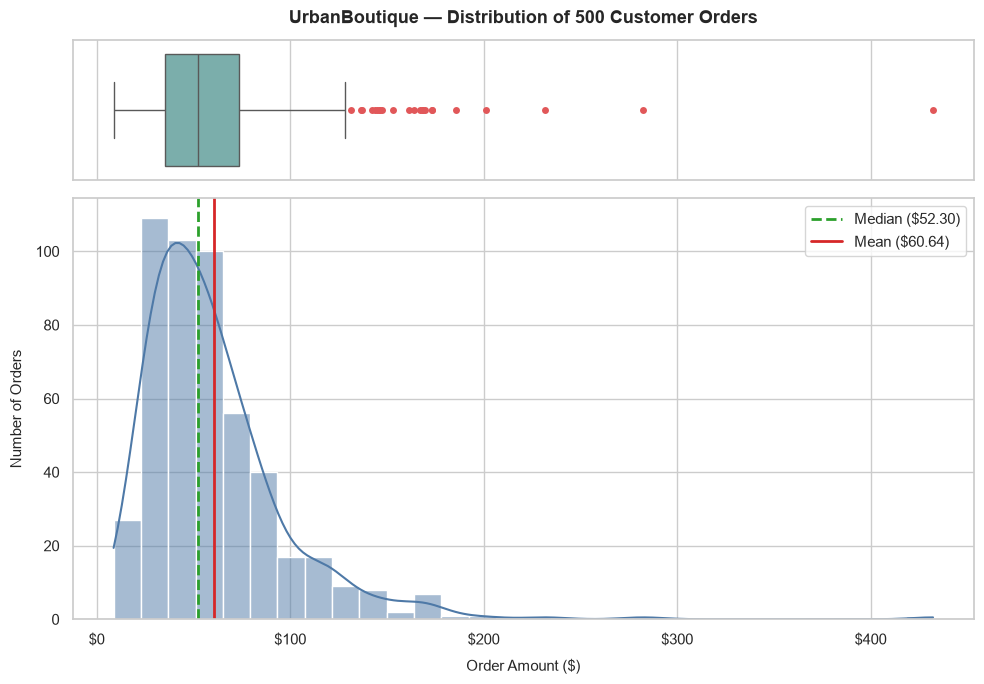

In [6]:
# Create a 2-row subplot comparing Histogram and Boxplot
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, 
                                      gridspec_kw={"height_ratios": [0.25, 0.75]})

# 1. Boxplot (top panel)
sns.boxplot(
    data=df,
    x="order_amount",
    ax=ax_box,
    color="#72b7b2",
    fliersize=5,
    flierprops={"markerfacecolor": "#e15759", "markeredgecolor": "none"}
)
ax_box.set(xlabel="")
ax_box.set_title("UrbanBoutique — Distribution of 500 Customer Orders", fontsize=13, fontweight="bold", pad=12)

# 2. Histogram with KDE (bottom panel)
sns.histplot(
    data=df,
    x="order_amount",
    ax=ax_hist,
    kde=True,
    bins=30,
    color="#4e79a7"
)

# Reference vertical lines for Mean and Median
mean_val = df["order_amount"].mean()
median_val = df["order_amount"].median()

ax_hist.axvline(median_val, color="#2ca02c", linestyle="--", linewidth=2, label=f"Median (${median_val:.2f})")
ax_hist.axvline(mean_val, color="#d62728", linestyle="-", linewidth=2, label=f"Mean (${mean_val:.2f})")

ax_hist.set_xlabel("Order Amount ($)", fontsize=11, labelpad=8)
ax_hist.set_ylabel("Number of Orders", fontsize=11, labelpad=8)
ax_hist.legend(loc="upper right", frameon=True)
ax_hist.xaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()
plt.show()


## 7. Plotly Express Visualization (Interactive Histogram & Boxplot)

Plotly Express allows you to combine histograms and boxplots into a single interactive figure using the `marginal` parameter.
- **Hover** over any histogram bin to see its exact price range and frequency count.
- **Hover** over the top boxplot to see exact quartile figures (Min, Q1, Median, Q3, Max, and Outliers).


In [7]:
# Interactive Histogram with Marginal Boxplot
fig = px.histogram(
    df,
    x="order_amount",
    nbins=35,
    marginal="box", # Adds boxplot at the top
    title="<b>Interactive Distribution of Order Amounts (with Marginal Boxplot)</b>",
    labels={"order_amount": "Order Amount ($)"},
    color_discrete_sequence=["#4e79a7"]
)

fig.update_layout(
    xaxis_title="Order Amount ($)",
    yaxis_title="Count of Orders",
    xaxis_tickprefix="$",
    template="plotly_white",
    bargap=0.05
)

fig.show()


## 8. Interpretation

By synthesizing the histogram and boxplot, we arrive at clear analytical interpretations:

1. **Right-Skewed Distribution (Positive Skew):**
   - The histogram displays a pronounced right tail extending all the way out past $300.
   - The highest frequency cluster (the mode) occurs between **$35 and $55**. Over 65% of all orders are under $70.

2. **Mean vs. Median Disparity:**
   - The **Median** is **$52.30**. Exactly half of all orders were less than this amount.
   - The **Arithmetic Mean** is **$60.64** — over **$8 higher** than the median!
   - Why? A handful of large outlier orders ($180, $250, $432) pull the mean upward like a lever, creating the false impression that a "typical" customer spends ~$61.

3. **Outlier Detection via IQR Rule:**
   - The boxplot reveals multiple red dots beyond the right whisker.
   - Mathematically, any order above $Q3 + 1.5 \times \text{IQR} = \$131.30$ is an outlier. While these 23 outlier orders represent 13.5% of total sales revenue, they are not representative of standard customer behavior.


## 9. Key Insights & Recommended Business Actions

### What Happened?
- Setting free shipping based on the mean ($75–$80) would set the bar too high: nearly **75% of customers currently spend less than $75**. Customers faced with an unreachable shipping threshold often abandon their carts.

### Actionable Business Recommendations:
1. **Set Strategic Free-Shipping Threshold at $65:**
   - The median is ~$55. A threshold of $65 is approximately 20% higher than the median order.
   - This motivates the majority of customers currently spending $45–$55 to add one more modest accessory (e.g., $15 socks or jewelry) to unlock free shipping, maximizing average order lift.
2. **Create a Dedicated VIP Program for High Outliers:**
   - Orders exceeding $150 represent high-spending VIP customers. Route these orders to premium priority packaging and include personalized thank-you vouchers.

---

### Common Analytical Mistake to Avoid:
> **Mistake: Relying Solely on the Mean for Skewed Data**  
> In business, metrics like revenue per user, customer order size, salaries, and website session lengths are virtually always right-skewed. Reporting only the mean misrepresents the typical experience. **Always report both the median and the mean**, or accompany the summary with a histogram or boxplot.


## 10. Practice Exercises

### Exercise 1: Chart Interpretation
Based on the distribution charts:
1. In your own words, explain why the arithmetic mean is significantly higher than the median in this dataset.
2. What does the width of the box in a boxplot represent?
3. If an analyst only saw the minimum ($15) and maximum ($340), what crucial information about the data distribution would they miss?


### Exercise 2: Modify Chart Settings (Adjusting Bin Width)
Histogram interpretation is sensitive to the number of bins selected.
In the code cell below:
- Create a Seaborn histogram with **`bins=10`** (coarse binning).
- Create a second Seaborn histogram with **`bins=60`** (fine binning).
- Observe how changing bin size changes your perception of the distribution.


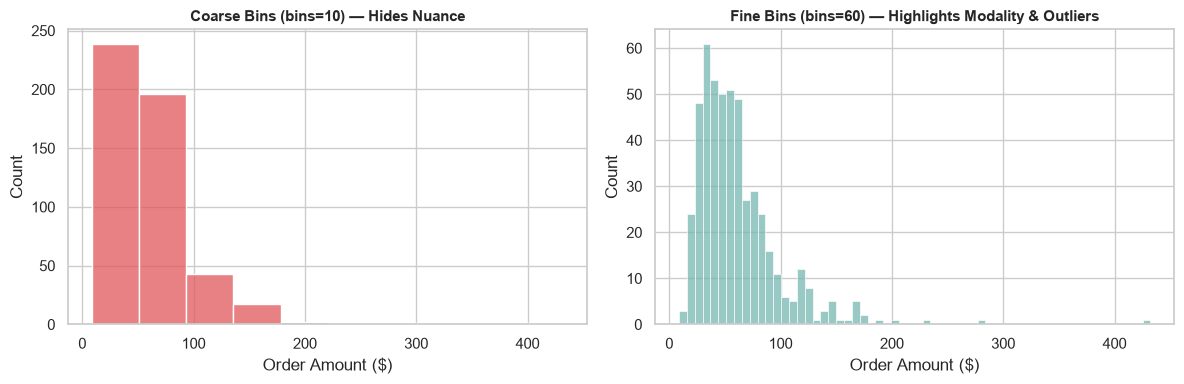

In [8]:
# Exercise 2: Student Code
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Coarse binning (10 bins)
sns.histplot(data=df, x="order_amount", bins=10, ax=ax1, color="#e15759")
ax1.set_title("Coarse Bins (bins=10) — Hides Nuance", fontsize=11, fontweight="bold")
ax1.set_xlabel("Order Amount ($)")

# Fine binning (60 bins)
sns.histplot(data=df, x="order_amount", bins=60, ax=ax2, color="#76b7b2")
ax2.set_title("Fine Bins (bins=60) — Highlights Modality & Outliers", fontsize=11, fontweight="bold")
ax2.set_xlabel("Order Amount ($)")

plt.tight_layout()
plt.show()


### Exercise 3: Answer a Business Question (Outlier Calculation)
Using Pandas, calculate the exact **Tukey Upper Outlier Threshold**:
$$\text{Upper Fence} = Q_3 + 1.5 \times (Q_3 - Q_1)$$
Then count how many orders in the dataset qualify as statistical outliers and calculate what percentage of total company revenue they generate.


In [9]:
# Exercise 3: Student Code
q1 = df["order_amount"].quantile(0.25)
q3 = df["order_amount"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

outliers = df[df["order_amount"] > upper_fence]
outlier_count = len(outliers)
outlier_rev_pct = (outliers["order_amount"].sum() / df["order_amount"].sum()) * 100

print(f"25th Percentile (Q1): ${q1:.2f}")
print(f"75th Percentile (Q3): ${q3:.2f}")
print(f"Interquartile Range (IQR): ${iqr:.2f}")
print(f"Upper Outlier Threshold: ${upper_fence:.2f}")
print(f"Total Outlier Orders: {outlier_count} out of 500 ({outlier_count/len(df)*100:.1f}%)")
print(f"Outlier Revenue Share: {outlier_rev_pct:.1f}% of total dollar sales")


25th Percentile (Q1): $35.33
75th Percentile (Q3): $73.72
Interquartile Range (IQR): $38.39
Upper Outlier Threshold: $131.30
Total Outlier Orders: 23 out of 500 (4.6%)
Outlier Revenue Share: 13.5% of total dollar sales


## 11. Challenge Activity

**Customer Spending Segmentation:**  
A common analytical practice is segmenting a continuous distribution into actionable commercial tiers.

1. Create a new column called `tier` based on spending:
   - **`"Budget"`**: Under $40
   - **`"Standard"`**: $40 to $80
   - **`"Premium"`**: $80 to $150
   - **`"VIP"`**: Over $150
2. Create an interactive Plotly boxplot showing `order_amount` grouped by `tier`.
3. Write two business insights on how marketing can tailor promotions to each tier.


In [10]:
# Challenge Activity: Tier segmentation and boxplot
# Define tier bins and labels
bins = [0, 40, 80, 150, np.inf]
labels = ["Budget (<$40)", "Standard ($40-$80)", "Premium ($80-$150)", "VIP (>$150)"]
df["tier"] = pd.cut(df["order_amount"], bins=bins, labels=labels)

# Plot interactive boxplot by tier
fig_tiers = px.box(
    df,
    x="tier",
    y="order_amount",
    color="tier",
    points="all", # Show individual jittered points
    title="<b>Customer Order Amounts Segmented by Spending Tier</b>",
    labels={"tier": "Customer Tier", "order_amount": "Order Amount ($)"}
)
fig_tiers.update_layout(template="plotly_white", showlegend=False)
fig_tiers.show()

# Print counts by tier
print(df["tier"].value_counts().sort_index())


tier
Budget (<$40)         165
Standard ($40-$80)    232
Premium ($80-$150)     89
VIP (>$150)            14
Name: count, dtype: int64


## 12. Key Takeaways

- **Always Inspect the Shape:** Never assume data follows a symmetrical bell curve. Real-world business data is frequently right-skewed.
- **Histograms Show Shape; Boxplots Show Summary:** Histograms reveal modality (single vs multiple peaks) and granularity; boxplots cleanly summarize quartiles and flag outliers.
- **Median Over Mean for Skewed Metrics:** When distributions have heavy tails or extreme outliers, the median is a much more robust indicator of central tendency.
- **Outliers Are Actionable:** Outliers should not just be discarded as errors; in business analytics, positive outliers often represent your most lucrative customer opportunities.
